In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

data = pd.read_csv(url)

data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [4]:
data.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [5]:
data = data.dropna()

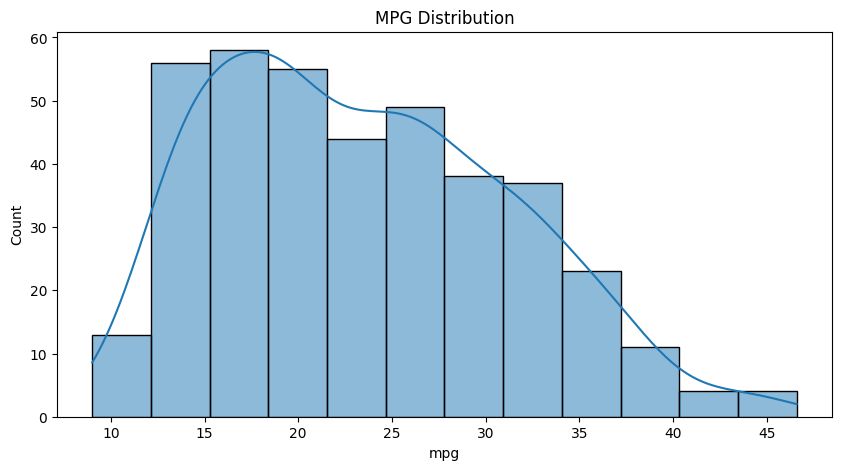

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(data['mpg'], kde=True)

plt.title("MPG Distribution")

plt.show()

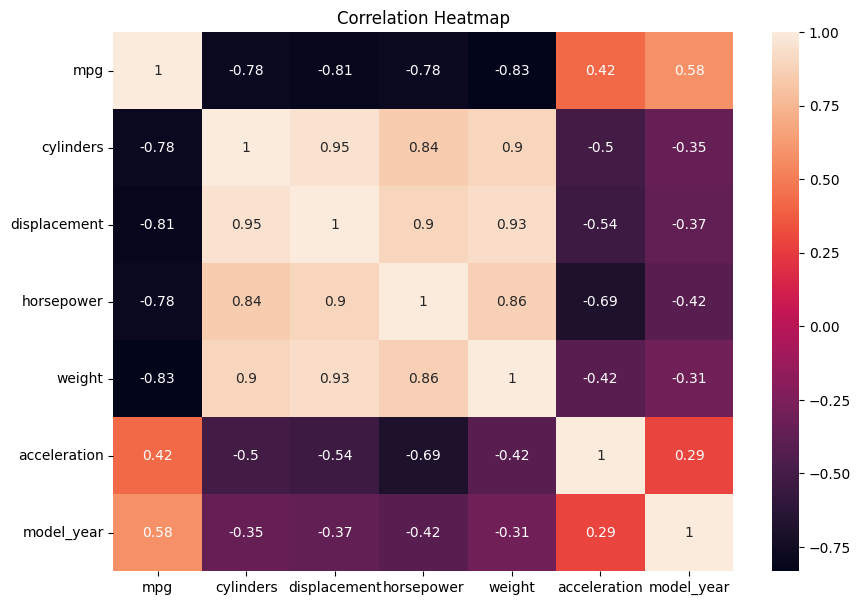

In [7]:
plt.figure(figsize=(10,7))

sns.heatmap(data.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

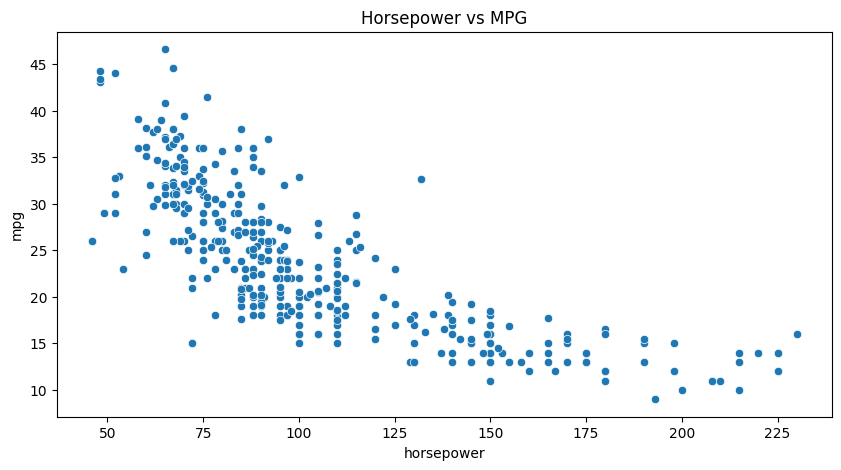

In [8]:
plt.figure(figsize=(10,5))

sns.scatterplot(x=data['horsepower'], y=data['mpg'])

plt.title("Horsepower vs MPG")

plt.show()

In [10]:
X = data[['cylinders', 'displacement', 'horsepower',
          'weight', 'acceleration', 'model_year']]

y = data['mpg']
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [13]:
predictions = model.predict(X_test)

print(predictions[:5])

[25.93279618 26.29927859 32.96548909 26.8544302  29.45372581]


In [14]:
mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Squared Error: 10.502370329417325
R2 Score: 0.7942349075428586


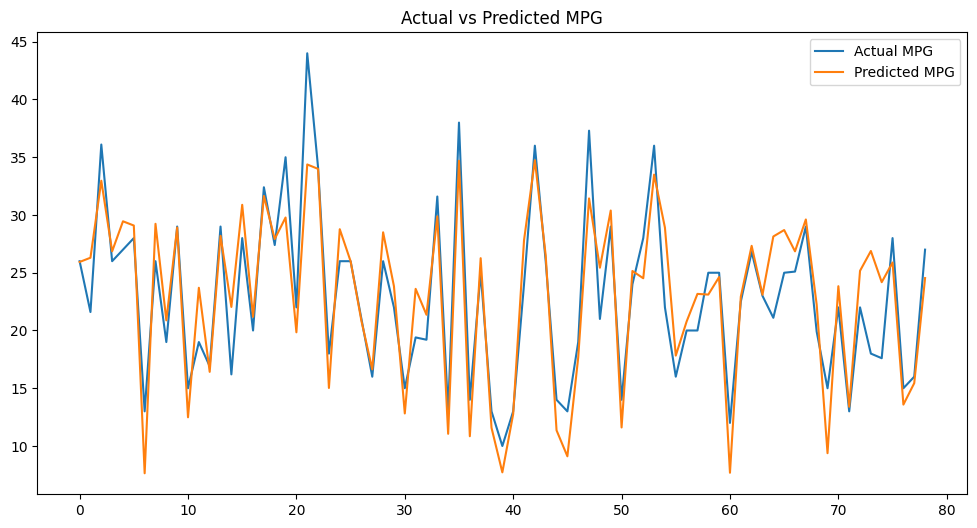

In [15]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual MPG')

plt.plot(predictions, label='Predicted MPG')

plt.legend()

plt.title("Actual vs Predicted MPG")

plt.show()

In [16]:
new_car = np.array([[4, 140, 90, 2500, 15, 82]])

prediction = model.predict(new_car)

print("Predicted MPG:", prediction[0])

Predicted MPG: 31.31027086922428


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
